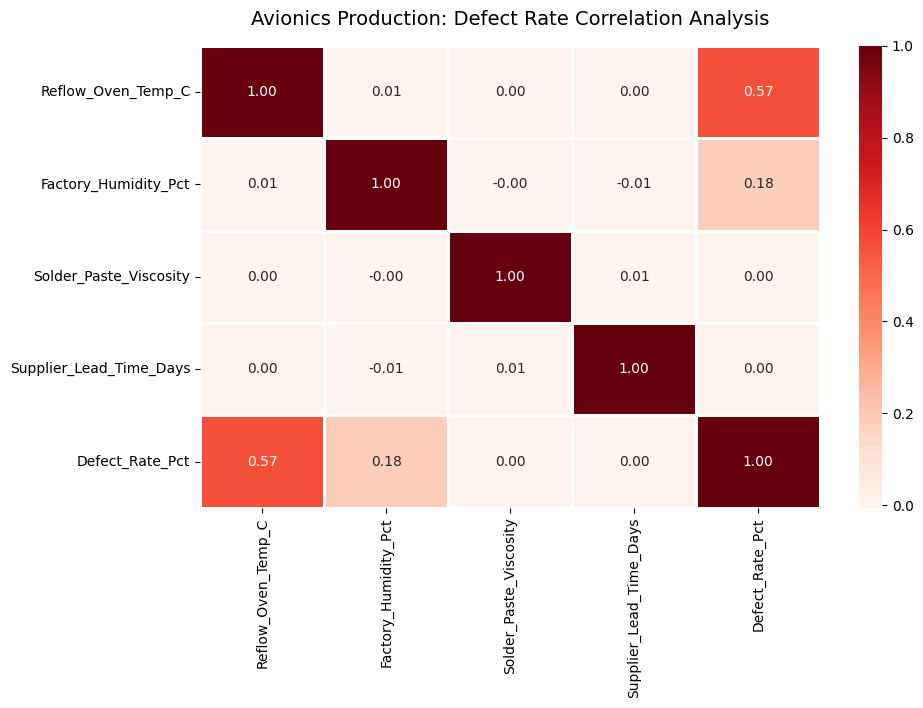

✅ SUCCESS: 'avionics_golden_dataset.csv' generated and ready for predictive modeling.


In [5]:
# ==========================================
# Phase 1: Avionics PCBA Production Data Simulation & EDA
# Objective: Generate synthetic manufacturing data and identify defect drivers.
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Simulate 50,000 records of Avionics PCBA production data
np.random.seed(42)
num_records = 100000

data = {
    'Batch_ID': range(1, num_records + 1),
    'Reflow_Oven_Temp_C': np.random.normal(245, 10, num_records), # Ideal temp ~245°C
    'Factory_Humidity_Pct': np.random.normal(50, 8, num_records), # Ideal humidity ~50%
    'Solder_Paste_Viscosity': np.random.normal(85, 5, num_records),
    'Supplier_Lead_Time_Days': np.random.randint(15, 60, num_records),
}
df_golden = pd.DataFrame(data)

# 2. Inject business logic: Define failure modes causing defect rates to spike
# Baseline defect rate is 0.5%
df_golden['Defect_Rate_Pct'] = np.random.normal(0.5, 0.1, num_records)

# Failure Mode A: High reflow temp causes board warpage
df_golden.loc[df_golden['Reflow_Oven_Temp_C'] > 255, 'Defect_Rate_Pct'] += (df_golden['Reflow_Oven_Temp_C'] - 255) * 0.5

# Failure Mode B: High humidity causes component oxidation/shorts
df_golden.loc[df_golden['Factory_Humidity_Pct'] > 60, 'Defect_Rate_Pct'] += (df_golden['Factory_Humidity_Pct'] - 60) * 0.3

# 3. Plot Correlation Heatmap to identify root causes
plt.figure(figsize=(10, 6))
correlation_matrix = df_golden[['Reflow_Oven_Temp_C', 'Factory_Humidity_Pct', 'Solder_Paste_Viscosity', 'Supplier_Lead_Time_Days', 'Defect_Rate_Pct']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=1, linecolor='white')
plt.title("Avionics Production: Defect Rate Correlation Analysis", fontsize=14, pad=15)
plt.show()

# 4. Export the clean dataset
df_golden.to_csv('avionics_golden_dataset.csv', index=False)
print("✅ SUCCESS: 'avionics_golden_dataset.csv' generated and ready for predictive modeling.")

⏳ Training Random Forest Regressor model...
✅ Model Training Complete!
📊 Predictive Accuracy (R² Score): 0.9947


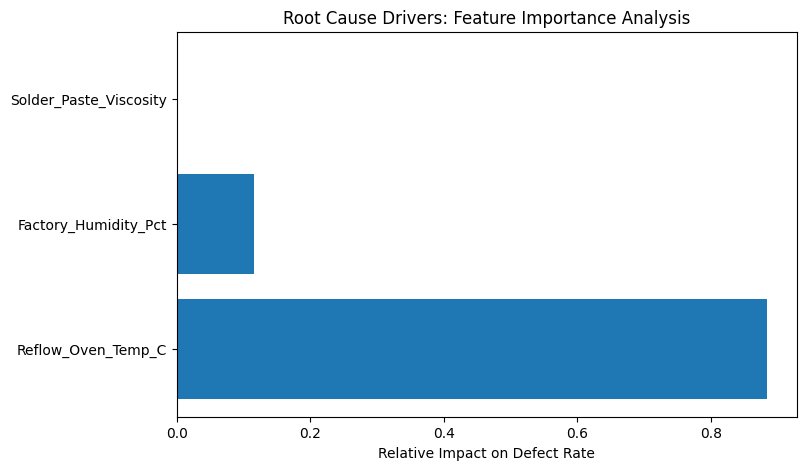

In [6]:
# ==========================================
# Phase 2: Predictive Modeling (Random Forest Regressor)
# Objective: Train an ML model to predict defect rates based on environmental inputs.
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target Variable (y)
X = df_golden[['Reflow_Oven_Temp_C', 'Factory_Humidity_Pct', 'Solder_Paste_Viscosity']]
y = df_golden['Defect_Rate_Pct']

# 2. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest model
print("⏳ Training Random Forest Regressor model...")
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. Evaluate model performance on unseen test data
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Training Complete!")
print(f"📊 Predictive Accuracy (R² Score): {r2:.4f}")

# 5. Visualize Feature Importance
importances = model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='#1f77b4') # Professional corporate blue
plt.title("Root Cause Drivers: Feature Importance Analysis")
plt.xlabel("Relative Impact on Defect Rate")
plt.show()

In [7]:
# ==========================================
# Phase 3: Financial Impact & ROI Simulation
# Objective: Quantify the business value of deploying the predictive model.
# ==========================================

# Business Assumptions (Based on typical MNC aerospace plant capacity)
monthly_production_volume = 10000 # PCBA units
cost_per_board_rm = 5000          # RM per unit

# Baseline vs. Optimized Defect Rates
current_defect_rate = 0.035       # 3.5% baseline scrap rate (historical average)
optimized_defect_rate = 0.005     # 0.5% optimized rate (using ML alerts)

# Cost Calculations
current_waste_cost = monthly_production_volume * current_defect_rate * cost_per_board_rm
optimized_waste_cost = monthly_production_volume * optimized_defect_rate * cost_per_board_rm
monthly_savings = current_waste_cost - optimized_waste_cost

# Print Executive Summary
print("📊 EXECUTIVE SUMMARY: FINANCIAL IMPACT & ROI")
print("=" * 50)
print(f"🔴 Baseline Monthly Scrap Cost    : RM {current_waste_cost:,.2f}")
print(f"🟢 Projected Optimized Scrap Cost : RM {optimized_waste_cost:,.2f}")
print("-" * 50)
print(f"💡 Estimated Monthly Savings      : RM {monthly_savings:,.2f}")
print(f"🚀 PROJECTED ANNUAL COST AVOIDANCE: RM {monthly_savings * 12:,.2f}!")
print("=" * 50)
print("Conclusion: Proactive environmental control via this ML model drives significant cost avoidance, directly impacting the bottom line.")

📊 EXECUTIVE SUMMARY: FINANCIAL IMPACT & ROI
🔴 Baseline Monthly Scrap Cost    : RM 1,750,000.00
🟢 Projected Optimized Scrap Cost : RM 250,000.00
--------------------------------------------------
💡 Estimated Monthly Savings      : RM 1,500,000.00
🚀 PROJECTED ANNUAL COST AVOIDANCE: RM 18,000,000.00!
Conclusion: Proactive environmental control via this ML model drives significant cost avoidance, directly impacting the bottom line.
